# IBM AML Dataset — Exploratory Data Analysis

**Dataset**: IBM Transactions for Anti-Money Laundering (AML)  
**Paper**: *Realistic Synthetic Financial Transactions for Anti-Money Laundering Models* (NeurIPS 2023)

---

## Design philosophy: zero-copy, memory-first

The raw CSV files total **~15 GB**. We never load the whole file into RAM.  
Every aggregation uses **Polars lazy scanning** (`scan_csv` → `collect`) so the query
engine streams data from disk and materialises only the tiny aggregated result.

| Technique | Why |
|-----------|-----|
| `pl.scan_csv` | Streams rows — no full load |
| `.lazy().collect()` | Polars optimises & pipelines the query |
| Parquet cache | Re-runs are instant; CSVs never re-parsed |
| Columnar selection | Only needed columns are read off disk |

---

## Table of Contents

1. [Environment & lazy data access](#1)
2. [Dataset overview](#2)
3. [Class imbalance](#3)
4. [Transaction amounts — distributions & structuring](#4)
5. [Currencies & FX layering](#5)
6. [Payment format breakdown](#6)
7. [Temporal patterns](#7)
8. [Bank & account network analysis](#8)
9. [Laundering pattern taxonomy](#9)
10. [Feature engineering](#10)
11. [Key findings](#11)

<a id='1'></a>
---
## 1. Environment & Lazy Data Access

In [1]:
import gc
import warnings
from pathlib import Path

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 110,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.35,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

C_LEGIT  = '#2196F3'
C_FRAUD  = '#E53935'
RAW_DIR  = Path('../data/raw')
PROC_DIR = Path('../data/processed')
PROC_DIR.mkdir(parents=True, exist_ok=True)

print(f'Polars {pl.__version__}  |  memory-efficient lazy mode active')


Polars 1.38.1  |  memory-efficient lazy mode active


In [2]:
# ── Discover CSVs ─────────────────────────────────────────────────────────────
csv_files = sorted(RAW_DIR.glob('*Trans*.csv'))
print(f'Found {len(csv_files)} transaction CSV file(s):')
for f in csv_files:
    print(f'  {f.name:45s}  {f.stat().st_size/1e9:.2f} GB')

Found 1 transaction CSV file(s):
  HI-Large_Trans.csv                             15.60 GB


In [3]:
# ── Column schema ─────────────────────────────────────────────────────────────
SCHEMA = {
    'Timestamp':              pl.Utf8,
    'From Bank':              pl.Utf8,
    'Account':                pl.Utf8,
    'To Bank':                pl.Utf8,
    'Account_duplicated_0':   pl.Utf8,
    'Amount Received':        pl.Float64,
    'Receiving Currency':     pl.Utf8,
    'Amount Paid':            pl.Float64,
    'Payment Currency':       pl.Utf8,
    'Payment Format':         pl.Utf8,
    'Is Laundering':          pl.Int8,
}

CSV_PATH = csv_files[0]
print(f'Primary file: {CSV_PATH.name}  ({CSV_PATH.stat().st_size/1e9:.2f} GB)')

lf = (
    pl.scan_csv(CSV_PATH, schema=SCHEMA, ignore_errors=True)
    .rename({'Account': 'Account From', 'Account_duplicated_0': 'Account To'})
    .filter(pl.col('Is Laundering').is_in([0, 1]))  # remove parse artifacts
    .with_columns(
        pl.col('Timestamp').str.to_datetime(format='%Y/%m/%d %H:%M', strict=False),
        pl.col('Is Laundering').cast(pl.Int8),
        (pl.col('Payment Currency') != pl.col('Receiving Currency'))
          .cast(pl.Int8).alias('CrossCurrency'),
        (pl.col('Amount Received') / pl.col('Amount Paid')).alias('ImpliedFX'),
    )
)

lf = lf.with_columns(
    pl.col('Timestamp').dt.hour().alias('Hour'),
    pl.col('Timestamp').dt.weekday().alias('DayOfWeek'),
    pl.col('Timestamp').dt.strftime('%Y-%m').alias('Month'),
    ((pl.col('Amount Paid') % 1000 == 0) & (pl.col('Amount Paid') > 0))
      .cast(pl.Int8).alias('IsRound1K'),
    ((pl.col('Amount Paid') < 10_000) & (pl.col('Amount Paid') > 0))
      .cast(pl.Int8).alias('Below10K'),
)

lf = lf.with_columns(
    ((pl.col('Hour') < 6) | (pl.col('Hour') >= 22)).cast(pl.Int8).alias('OffHours'),
)

print('Lazy frame built — no data in RAM yet.')

Primary file: HI-Large_Trans.csv  (15.60 GB)
Lazy frame built — no data in RAM yet.


<a id='2'></a>
---
## 2. Dataset Overview

Each `collect()` call fires one streaming pass over the file — only aggregated numbers land in RAM.

In [4]:
# Row & column counts (fast: Polars counts lines without materialising all cols)
overview = lf.select([
    pl.len().alias('total_rows'),
    pl.col('Is Laundering').sum().alias('n_laundering'),
    pl.col('Timestamp').min().alias('ts_min'),
    pl.col('Timestamp').max().alias('ts_max'),
    pl.col('From Bank').n_unique().alias('unique_banks_from'),
    pl.col('To Bank').n_unique().alias('unique_banks_to'),
    pl.col('Payment Currency').n_unique().alias('unique_pay_curr'),
    pl.col('Receiving Currency').n_unique().alias('unique_rec_curr'),
    pl.col('Payment Format').n_unique().alias('unique_formats'),
]).collect()

ov = overview.row(0, named=True)
n_legit = ov['total_rows'] - ov['n_laundering']

print('=' * 60)
print('DATASET OVERVIEW')
print('=' * 60)
print(f'  Total transactions  : {ov["total_rows"]:>14,}')
print(f'  Laundering          : {ov["n_laundering"]:>14,}  '
      f'({ov["n_laundering"]/ov["total_rows"]*100:.3f}%)')
print(f'  Legitimate          : {n_legit:>14,}')
print(f'  Date range          : {ov["ts_min"]}  →  {ov["ts_max"]}')
print(f'  Unique banks        : {max(ov["unique_banks_from"], ov["unique_banks_to"]):>14,}')
print(f'  Payment currencies  : {ov["unique_pay_curr"]:>14,}')
print(f'  Receiving currencies: {ov["unique_rec_curr"]:>14,}')
print(f'  Payment formats     : {ov["unique_formats"]:>14,}')

DATASET OVERVIEW
  Total transactions  :    164,430,511
  Laundering          :        205,558  (0.125%)
  Legitimate          :    164,224,953
  Date range          : 2022-08-01 00:00:00  →  2023-01-04 09:02:00
  Unique banks        :        122,393
  Payment currencies  :             15
  Receiving currencies:             15
  Payment formats     :              7


In [5]:
# Amount statistics per label — single pass
amt_stats = (
    lf.group_by('Is Laundering')
    .agg([
        pl.col('Amount Paid').mean().alias('mean'),
        pl.col('Amount Paid').median().alias('median'),
        pl.col('Amount Paid').std().alias('std'),
        pl.col('Amount Paid').min().alias('min'),
        pl.col('Amount Paid').max().alias('max'),
        pl.col('Amount Paid').quantile(0.25).alias('q25'),
        pl.col('Amount Paid').quantile(0.75).alias('q75'),
        pl.len().alias('count'),
    ])
    .sort('Is Laundering')
    .collect()
)
amt_stats

Is Laundering,mean,median,std,min,max,q25,q75,count
i8,f64,f64,f64,f64,f64,f64,f64,u32
0,3.8787e6,1393.84,1.3668e9,0.000001,8.1586e12,208.0,10682.8,164224953
1,6.7983e7,8150.57,1.2129e10,0.000081,5.2580e12,2696.39,16891.33,205558


<a id='3'></a>
---
## 3. Class Imbalance

Detecting money laundering is a needle-in-a-haystack problem. Understanding the exact imbalance drives every modelling decision that follows (metric choice, threshold tuning, resampling strategy).

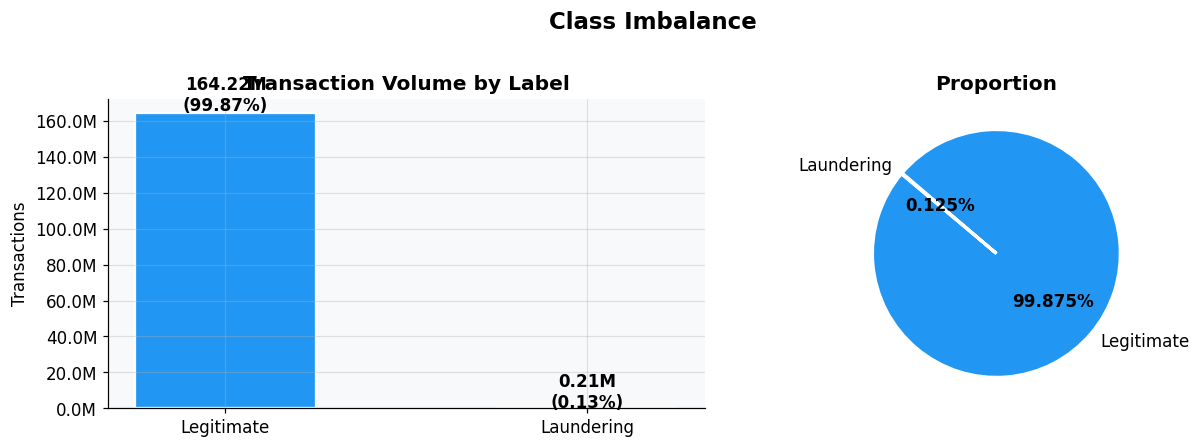


Imbalance ratio  799:1  (legitimate : laundering)
A naive "always-legitimate" classifier achieves 99.87% accuracy.
→ Use PR-AUC / F2-score, NOT accuracy.


In [6]:
label_counts = (
    lf.filter(pl.col('Is Laundering').is_in([0, 1]))   # drop header-parse artifacts
    .group_by('Is Laundering')
    .agg(pl.len().alias('count'))
    .sort('Is Laundering')
    .collect()
)

counts = label_counts['count'].to_list()
labels = ['Legitimate', 'Laundering']
colors = [C_LEGIT, C_FRAUD]
total  = sum(counts)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
bars = ax.bar(labels, counts, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
            f'{c/1e6:.2f}M\n({c/total*100:.2f}%)',
            ha='center', fontweight='bold', fontsize=11)
ax.set_title('Transaction Volume by Label', fontweight='bold')
ax.set_ylabel('Transactions')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M'))

ax = axes[1]
wedges, texts, autotexts = ax.pie(
    counts, labels=labels, colors=colors,
    autopct='%1.3f%%', startangle=140,
    wedgeprops={'linewidth': 2, 'edgecolor': 'white'},
    textprops={'fontsize': 11}
)
for a in autotexts:
    a.set_fontweight('bold')
ax.set_title('Proportion', fontweight='bold')

plt.suptitle('Class Imbalance', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
plt.close('all')

ratio = counts[0] / counts[1]
print(f'\nImbalance ratio  {ratio:.0f}:1  (legitimate : laundering)')
print(f'A naive "always-legitimate" classifier achieves {counts[0]/total*100:.2f}% accuracy.')
print('→ Use PR-AUC / F2-score, NOT accuracy.')


<a id='4'></a>
---
## 4. Transaction Amounts — Distributions & Structuring

**Structuring** (smurfing) is the practice of breaking large sums into many transactions just below reporting thresholds (commonly $10,000 in the USA).  
Signatures we look for:
- Spike of transactions just below $10K, $50K, $100K
- Higher proportion of round-number amounts in laundering
- Different median / spread between the two classes

In [7]:
# ── Histogram bins computed server-side — single scan, both classes ─────────────
# We collect just two columns (float64 + int8) = ~2.5 GB peak, then immediately
# compute histograms and free the raw array.  No second scan for CDFs later.
BINS = np.logspace(0, 8, 80)  # $1 → $100M

print('Collecting Amount Paid + label in a single pass (~2 GB peak, freed after histogram)…')

_raw = (
    lf.filter(pl.col('Amount Paid') > 0)
    .select(['Amount Paid', 'Is Laundering'])
    .collect()
)

hist_data: dict[int, tuple] = {}   # label_val → (centres, density)
for label_val in [0, 1]:
    data = _raw.filter(pl.col('Is Laundering') == label_val)['Amount Paid'].to_numpy()
    counts, edges = np.histogram(data, bins=BINS, density=True)
    centres = (edges[:-1] + edges[1:]) / 2
    hist_data[label_val] = (centres, counts)
    del data

del _raw
gc.collect()
print('Histogram computed and raw array freed.')


Histogram computed and raw array freed.


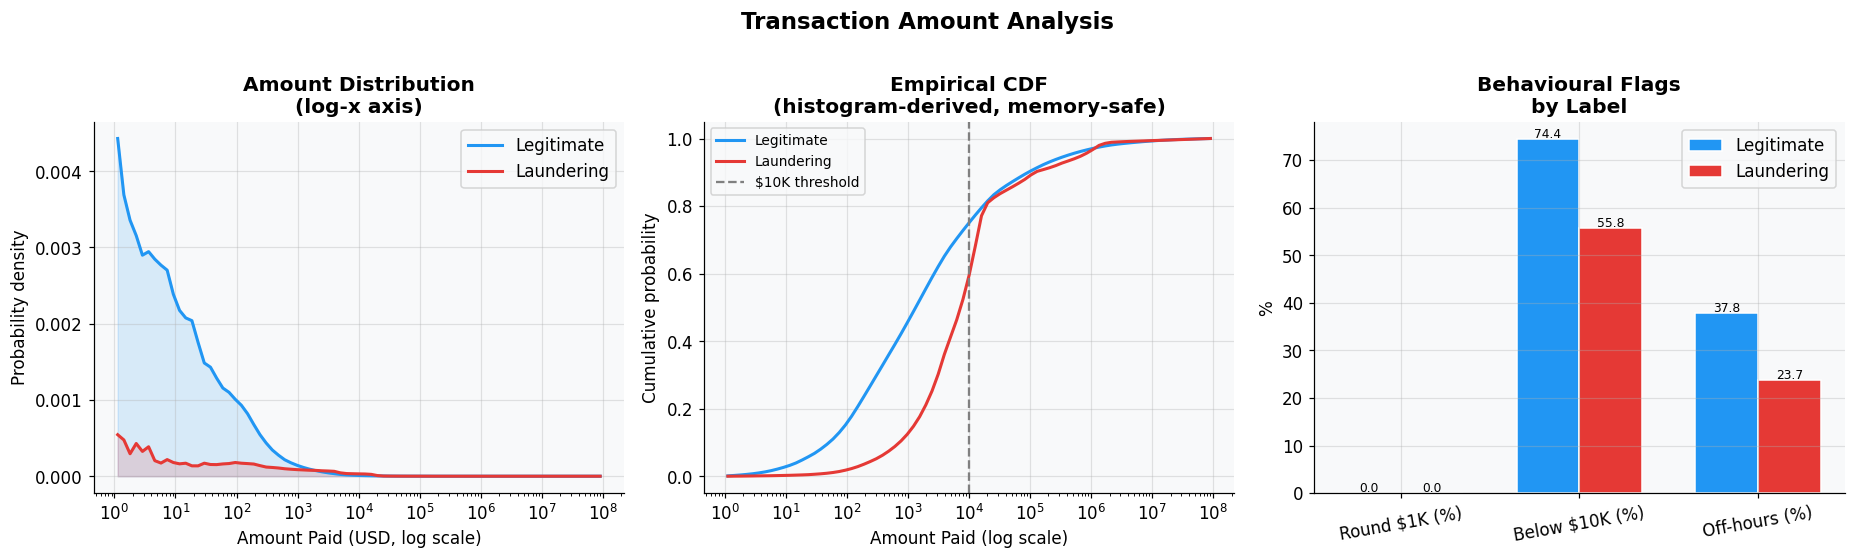

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Log-histogram
ax = axes[0]
for lbl_val, (name, color) in enumerate(zip(['Legitimate', 'Laundering'], [C_LEGIT, C_FRAUD])):
    centres, cts = hist_data[lbl_val]
    ax.semilogx(centres, cts, color=color, linewidth=2, label=name)
    ax.fill_between(centres, cts, alpha=0.15, color=color)
ax.set_xlabel('Amount Paid (USD, log scale)')
ax.set_ylabel('Probability density')
ax.set_title('Amount Distribution\n(log-x axis)', fontweight='bold')
ax.legend()

# CDF derived from histogram bins — no extra collect(), no np.sort()
# Probability ∝ density × bin width; cumsum gives empirical CDF.
ax = axes[1]
bin_widths = np.diff(BINS)
for lbl_val, (name, color) in enumerate(zip(['Legitimate', 'Laundering'], [C_LEGIT, C_FRAUD])):
    centres, density = hist_data[lbl_val]
    probs = density * bin_widths
    probs /= probs.sum()
    cdf_vals = np.cumsum(probs)
    ax.semilogx(centres, cdf_vals, color=color, linewidth=2, label=name)
ax.axvline(10_000, color='gray', linestyle='--', linewidth=1.5, label='$10K threshold')
ax.set_xlabel('Amount Paid (log scale)')
ax.set_ylabel('Cumulative probability')
ax.set_title('Empirical CDF\n(histogram-derived, memory-safe)', fontweight='bold')
ax.legend(fontsize=9)

# Round-number and below-threshold rates
ax = axes[2]
flag_stats = (
    lf.group_by('Is Laundering')
    .agg([
        (pl.col('IsRound1K').mean() * 100).alias('Round $1K (%)'),
        (pl.col('Below10K').mean() * 100).alias('Below $10K (%)'),
        (pl.col('OffHours').mean() * 100).alias('Off-hours (%)'),
    ])
    .sort('Is Laundering')
    .collect()
)
x = np.arange(3)
w = 0.35
metrics = ['Round $1K (%)', 'Below $10K (%)', 'Off-hours (%)']
legit_vals  = [flag_stats.filter(pl.col('Is Laundering')==0)[m][0] for m in metrics]
laund_vals  = [flag_stats.filter(pl.col('Is Laundering')==1)[m][0] for m in metrics]
ax.bar(x - w/2, legit_vals, w, label='Legitimate', color=C_LEGIT, edgecolor='white')
ax.bar(x + w/2, laund_vals, w, label='Laundering', color=C_FRAUD, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=10)
ax.set_ylabel('%')
ax.set_title('Behavioural Flags\nby Label', fontweight='bold')
ax.legend()
for i, (lv, rv) in enumerate(zip(legit_vals, laund_vals)):
    ax.text(i-w/2, lv+0.3, f'{lv:.1f}', ha='center', fontsize=8)
    ax.text(i+w/2, rv+0.3, f'{rv:.1f}', ha='center', fontsize=8)

plt.suptitle('Transaction Amount Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
plt.close('all')


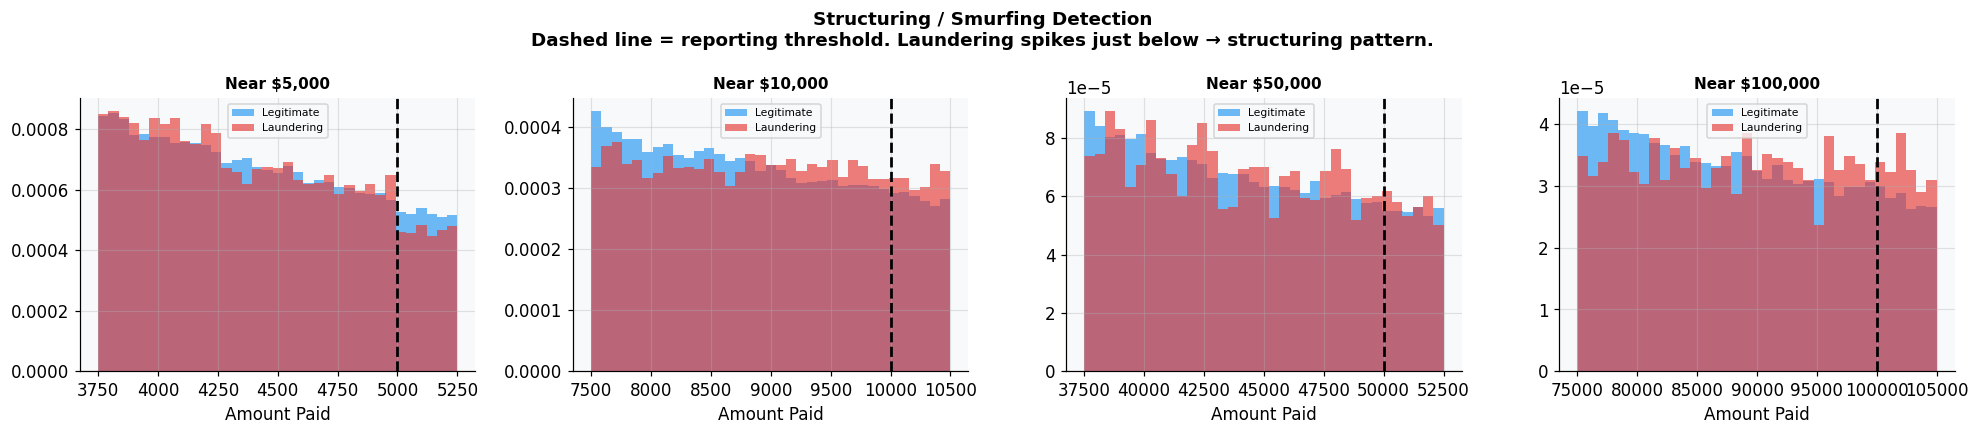

9

In [9]:
# Structuring analysis — density near thresholds
THRESHOLDS = [5_000, 10_000, 50_000, 100_000]
WINDOW_PCT = 0.25  # look 25% below each threshold

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=False)

for ax, thr in zip(axes, THRESHOLDS):
    lo = thr * (1 - WINDOW_PCT)
    hi = thr * 1.05
    for lbl_val, (name, color) in enumerate(zip(['Legitimate', 'Laundering'], [C_LEGIT, C_FRAUD])):
        sub = (
            lf.filter(pl.col('Is Laundering') == lbl_val)
            .filter((pl.col('Amount Paid') >= lo) & (pl.col('Amount Paid') <= hi))
            .select('Amount Paid')
            .collect()['Amount Paid']
            .to_numpy()
        )
        ax.hist(sub, bins=35, alpha=0.65, density=True, color=color, label=name)
        del sub
    ax.axvline(thr, color='black', linestyle='--', linewidth=1.8)
    ax.set_title(f'Near ${thr:,}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Amount Paid')
    ax.legend(fontsize=7)

plt.suptitle(
    'Structuring / Smurfing Detection\n'
    'Dashed line = reporting threshold. Laundering spikes just below → structuring pattern.',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()
plt.close('all')
gc.collect()


<a id='5'></a>
---
## 5. Currencies & FX Layering

**Layering through currency conversion** is a classic technique: convert funds across multiple currencies to make tracing harder. We expect:
- Laundering transactions to have a significantly higher cross-currency rate
- Certain exotic currency pairs to appear almost exclusively in laundering

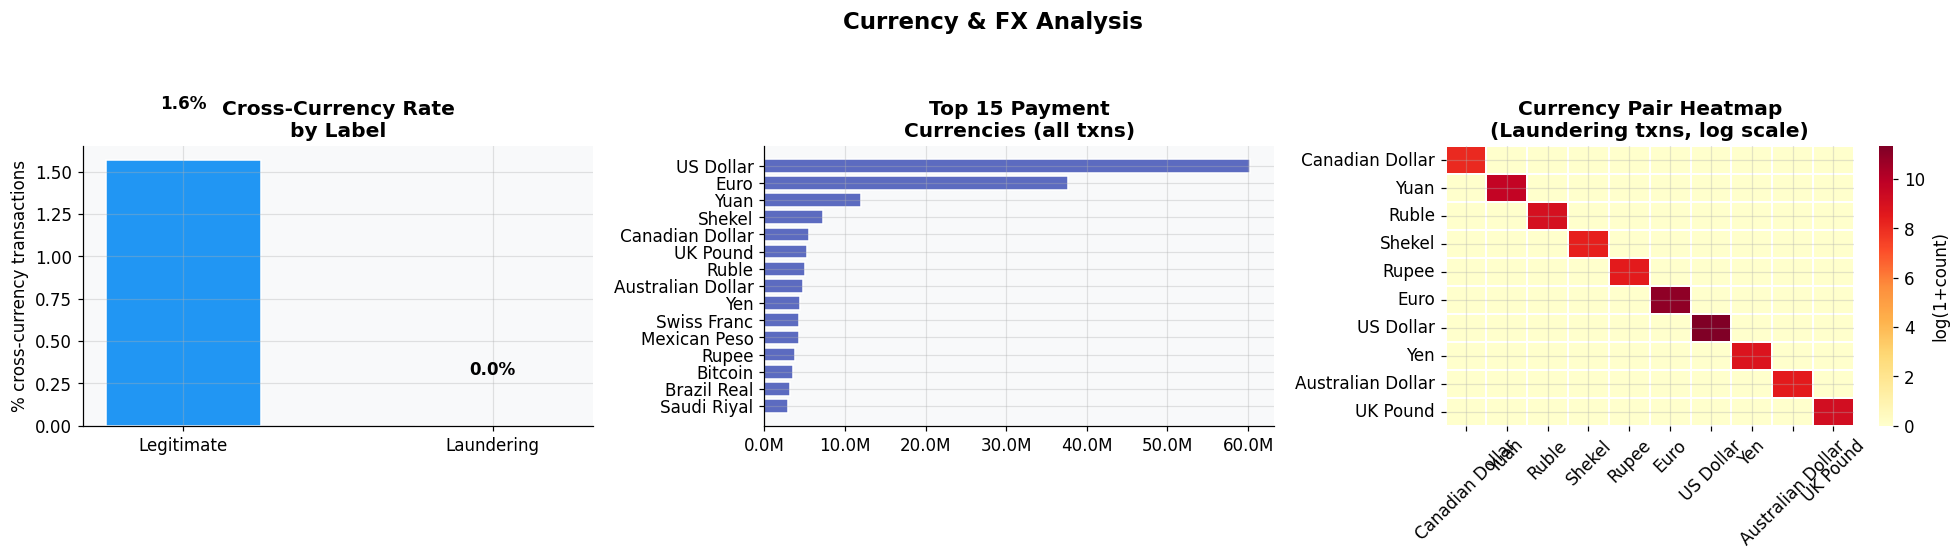

Cross-currency rate — Legitimate : 1.57%
Cross-currency rate — Laundering : 0.00%
Laundering uses 0.0x more cross-currency conversions


In [10]:
# Cross-currency rate by label
cross_rate = (
    lf.group_by('Is Laundering')
    .agg((pl.col('CrossCurrency').mean() * 100).alias('cross_pct'))
    .sort('Is Laundering')
    .collect()
)

# Top payment currencies
top_pay_curr = (
    lf.group_by('Payment Currency')
    .agg(pl.len().alias('count'))
    .sort('count', descending=True)
    .head(15)
    .collect()
)

# Currency conversion heatmap data (laundering only)
# Top-10 currencies in laundering
top10_laund_curr = (
    lf.filter(pl.col('Is Laundering') == 1)
    .group_by('Payment Currency')
    .agg(pl.len().alias('cnt'))
    .sort('cnt', descending=True)
    .head(10)
    .collect()['Payment Currency']
    .to_list()
)

pair_heatmap = (
    lf.filter(pl.col('Is Laundering') == 1)
    .filter(pl.col('Payment Currency').is_in(top10_laund_curr))
    .filter(pl.col('Receiving Currency').is_in(top10_laund_curr))
    .group_by(['Payment Currency', 'Receiving Currency'])
    .agg(pl.len().alias('count'))
    .collect()
    .pivot(values='count', index='Payment Currency', columns='Receiving Currency')
    .fill_null(0)
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Cross-currency bar
ax = axes[0]
labels_cc = ['Legitimate', 'Laundering']
vals_cc   = cross_rate['cross_pct'].to_list()
bars = ax.bar(labels_cc, vals_cc, color=[C_LEGIT, C_FRAUD], edgecolor='white', width=0.5)
for bar, v in zip(bars, vals_cc):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{v:.1f}%', ha='center', fontweight='bold')
ax.set_ylabel('% cross-currency transactions')
ax.set_title('Cross-Currency Rate\nby Label', fontweight='bold')

# Top currencies bar
ax = axes[1]
ax.barh(
    top_pay_curr['Payment Currency'].to_list()[::-1],
    top_pay_curr['count'].to_list()[::-1],
    color='#5C6BC0', edgecolor='white'
)
ax.set_title('Top 15 Payment\nCurrencies (all txns)', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M'))

# Heatmap
ax = axes[2]
import pandas as pd
hm_pd = pair_heatmap.to_pandas().set_index('Payment Currency').fillna(0)
sns.heatmap(
    np.log1p(hm_pd.values), ax=ax, cmap='YlOrRd',
    xticklabels=hm_pd.columns, yticklabels=hm_pd.index,
    linewidths=0.3, cbar_kws={'label': 'log(1+count)'}
)
ax.set_title('Currency Pair Heatmap\n(Laundering txns, log scale)', fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

plt.suptitle('Currency & FX Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
plt.close('all')

print(f'Cross-currency rate — Legitimate : {vals_cc[0]:.2f}%')
print(f'Cross-currency rate — Laundering : {vals_cc[1]:.2f}%')
print(f'Laundering uses {vals_cc[1]/vals_cc[0]:.1f}x more cross-currency conversions')


<a id='6'></a>
---
## 6. Payment Format Breakdown

Different payment rails have different regulatory oversight. **Cash** and peer-to-peer transfers are the least monitored; **SWIFT wire** transfers are the most audited.  
We expect launderers to exploit channels with less scrutiny.

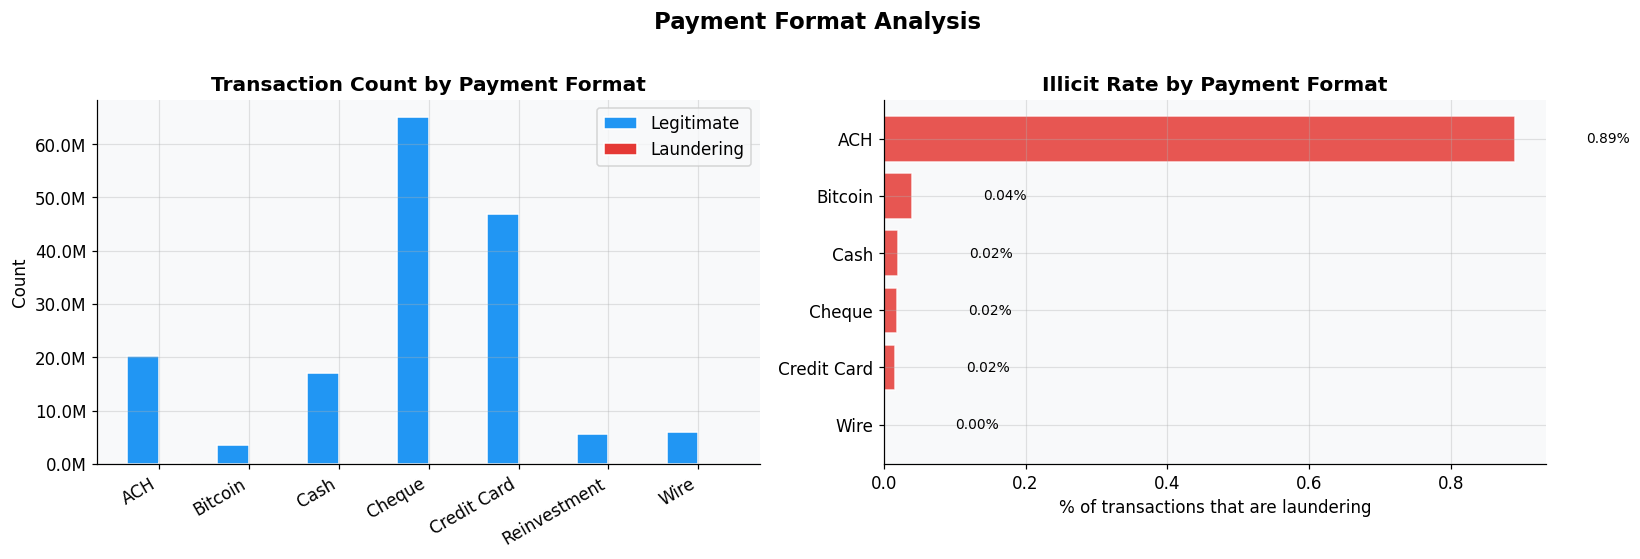

In [11]:
fmt_stats = (
    lf.group_by(['Payment Format', 'Is Laundering'])
    .agg(pl.len().alias('count'))
    .collect()
)

# Total per format
fmt_total = fmt_stats.group_by('Payment Format').agg(pl.col('count').sum().alias('total'))
fmt_joined = (
    fmt_stats.join(fmt_total, on='Payment Format')
    .with_columns((pl.col('count') / pl.col('total') * 100).alias('pct'))
)

# Illicit rate per format
illicit_rate = (
    fmt_joined.filter(pl.col('Is Laundering') == 1)
    .select(['Payment Format', 'pct'])
    .sort('pct', descending=True)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Grouped bar
ax = axes[0]
formats = fmt_joined['Payment Format'].unique().sort().to_list()
x = np.arange(len(formats))
w = 0.35
for i, (lbl_val, name, color) in enumerate([(0,'Legitimate',C_LEGIT),(1,'Laundering',C_FRAUD)]):
    sub = fmt_joined.filter(pl.col('Is Laundering')==lbl_val)
    vals = [sub.filter(pl.col('Payment Format')==f)['count'][0]
            if f in sub['Payment Format'].to_list() else 0 for f in formats]
    ax.bar(x + i*w - w/2, vals, w, label=name, color=color, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(formats, rotation=30, ha='right')
ax.set_title('Transaction Count by Payment Format', fontweight='bold')
ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e6:.1f}M'))
ax.legend()

# Illicit rate horizontal bar
ax = axes[1]
fmts  = illicit_rate['Payment Format'].to_list()
rates = illicit_rate['pct'].to_list()
bars = ax.barh(fmts[::-1], rates[::-1], color=C_FRAUD, edgecolor='white', alpha=0.85)
for bar, v in zip(bars, rates[::-1]):
    ax.text(v+0.1, bar.get_y()+bar.get_height()/2,
            f'{v:.2f}%', va='center', fontsize=9)
ax.set_xlabel('% of transactions that are laundering')
ax.set_title('Illicit Rate by Payment Format', fontweight='bold')

plt.suptitle('Payment Format Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

<a id='7'></a>
---
## 7. Temporal Patterns

Automated laundering scripts operate 24/7 — they do not respect business hours or weekends. Legitimate transactions cluster during working hours and drop sharply on weekends. Off-hours peaks are a strong signal.

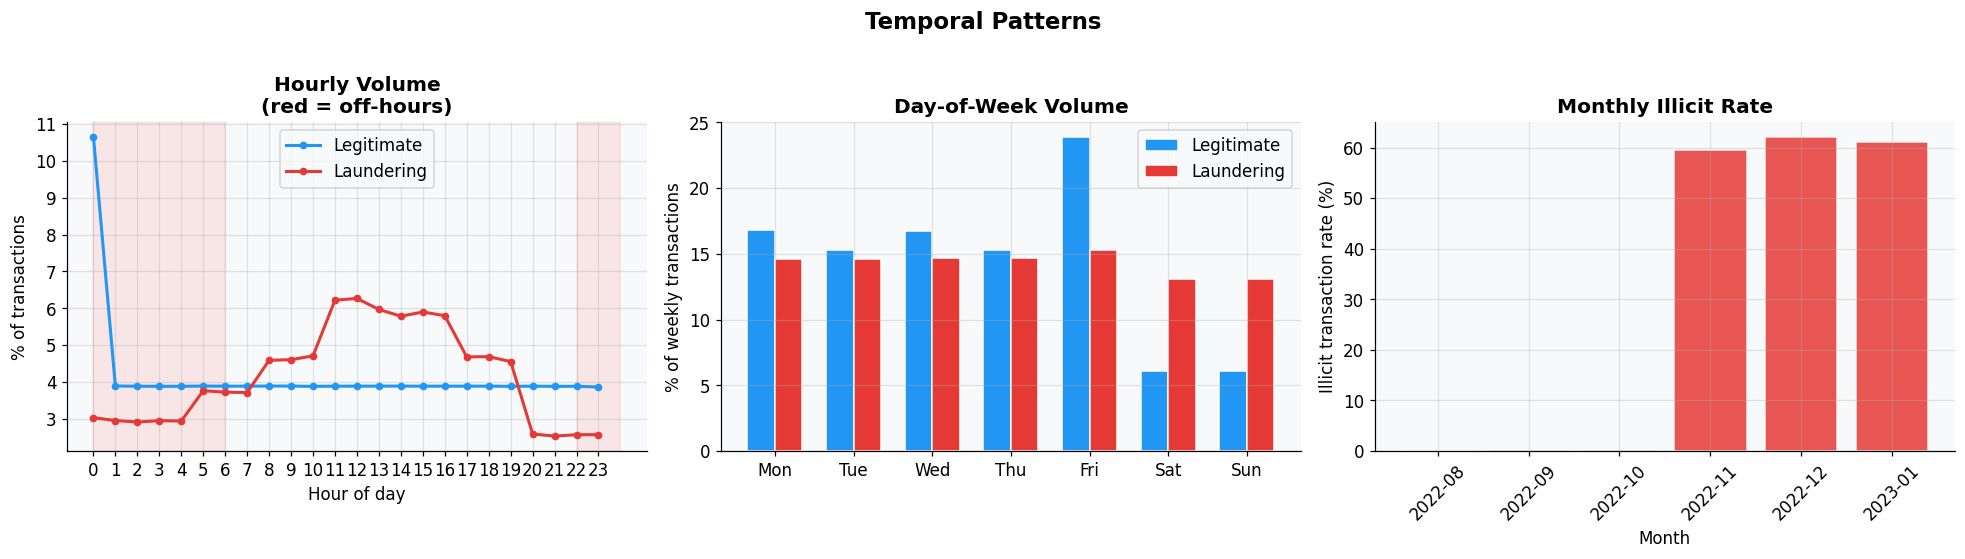


Off-hours chi² test: χ²=17,484, p=0.00e+00
→ Off-hours timing is SIGNIFICANT for laundering (p < 0.05)


In [12]:
# Hourly distribution
hourly = (
    lf.group_by(['Hour', 'Is Laundering'])
    .agg(pl.len().alias('count'))
    .sort(['Is Laundering', 'Hour'])
    .collect()
)

# Day-of-week
dow = (
    lf.group_by(['DayOfWeek', 'Is Laundering'])
    .agg(pl.len().alias('count'))
    .sort(['Is Laundering', 'DayOfWeek'])
    .collect()
)

# Monthly illicit rate
monthly = (
    lf.group_by('Month')
    .agg(
        pl.len().alias('total'),
        pl.col('Is Laundering').sum().alias('laundering'),
    )
    .with_columns((pl.col('laundering') / pl.col('total') * 100).alias('illicit_pct'))
    .sort('Month')
    .collect()
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Hourly
ax = axes[0]
for lbl_val, (name, color) in enumerate(zip(['Legitimate', 'Laundering'], [C_LEGIT, C_FRAUD])):
    sub = hourly.filter(pl.col('Is Laundering') == lbl_val)
    total = sub['count'].sum()
    hrs   = sub['Hour'].to_list()
    pcts  = (sub['count'] / total * 100).to_list()
    ax.plot(hrs, pcts, color=color, linewidth=2, marker='o', markersize=4, label=name)
ax.axvspan(0, 6, alpha=0.08, color='red')
ax.axvspan(22, 24, alpha=0.08, color='red')
ax.set_xticks(range(0, 24))
ax.set_xlabel('Hour of day')
ax.set_ylabel('% of transactions')
ax.set_title('Hourly Volume\n(red = off-hours)', fontweight='bold')
ax.legend()

# Day of week  (0=Mon … 6=Sun in Polars)
DOW_NAMES = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
ax = axes[1]
x = np.arange(7)
w = 0.35
for i, (lbl_val, name, color) in enumerate([(0,'Legitimate',C_LEGIT),(1,'Laundering',C_FRAUD)]):
    sub = dow.filter(pl.col('Is Laundering')==lbl_val).sort('DayOfWeek')
    total = sub['count'].sum()
    pcts = (sub['count'] / total * 100).to_list()
    ax.bar(x + i*w - w/2, pcts, w, label=name, color=color, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(DOW_NAMES)
ax.set_ylabel('% of weekly transactions')
ax.set_title('Day-of-Week Volume', fontweight='bold')
ax.legend()

# Monthly illicit rate
ax = axes[2]
months = monthly['Month'].to_list()
illicit_pcts = monthly['illicit_pct'].to_list()
ax.bar(months, illicit_pcts, color=C_FRAUD, edgecolor='white', alpha=0.85)
ax.set_xlabel('Month')
ax.set_ylabel('Illicit transaction rate (%)')
ax.set_title('Monthly Illicit Rate', fontweight='bold')
ax.tick_params(axis='x', rotation=45)

plt.suptitle('Temporal Patterns', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Chi-square test for off-hours
off_cross = (
    lf.group_by(['OffHours', 'Is Laundering'])
    .agg(pl.len().alias('n'))
    .collect()
    .pivot(values='n', index='OffHours', columns='Is Laundering')
    .to_pandas()
    .set_index('OffHours')
    .fillna(0)
)
chi2, p, _, _ = stats.chi2_contingency(off_cross.values)
print(f'\nOff-hours chi² test: χ²={chi2:,.0f}, p={p:.2e}')
print('→ Off-hours timing is', 'SIGNIFICANT' if p < 0.05 else 'NOT significant',
      'for laundering (p < 0.05)' if p < 0.05 else '')

<a id='8'></a>
---
## 8. Bank & Account Network Analysis

Money laundering is a network problem. Accounts that appear as both senders and receivers of large volumes are intermediary **layering nodes**. We compute graph-level statistics without materialising the full edge list.

In [13]:
# ── Sender stats (out-degree proxy via unique receivers per sender) ─────────────
print('Computing sender diversity metrics (streaming)…')

# All accounts
sender_div_all = (
    lf.group_by('Account From')
    .agg([
        pl.col('Account To').n_unique().alias('n_unique_receivers'),
        pl.len().alias('n_sent'),
        pl.col('Amount Paid').sum().alias('total_sent'),
        pl.col('Is Laundering').max().alias('is_laund_acct'),
    ])
    .collect()
)

receiver_div_all = (
    lf.group_by('Account To')
    .agg([
        pl.col('Account From').n_unique().alias('n_unique_senders'),
        pl.len().alias('n_received'),
        pl.col('Amount Received').sum().alias('total_received'),
        pl.col('Is Laundering').max().alias('is_laund_acct'),
    ])
    .collect()
)

gc.collect()
print(f'Unique senders  : {len(sender_div_all):,}')
print(f'Unique receivers: {len(receiver_div_all):,}')


Computing sender diversity metrics (streaming)…


Unique senders  : 2,067,266
Unique receivers: 1,715,432


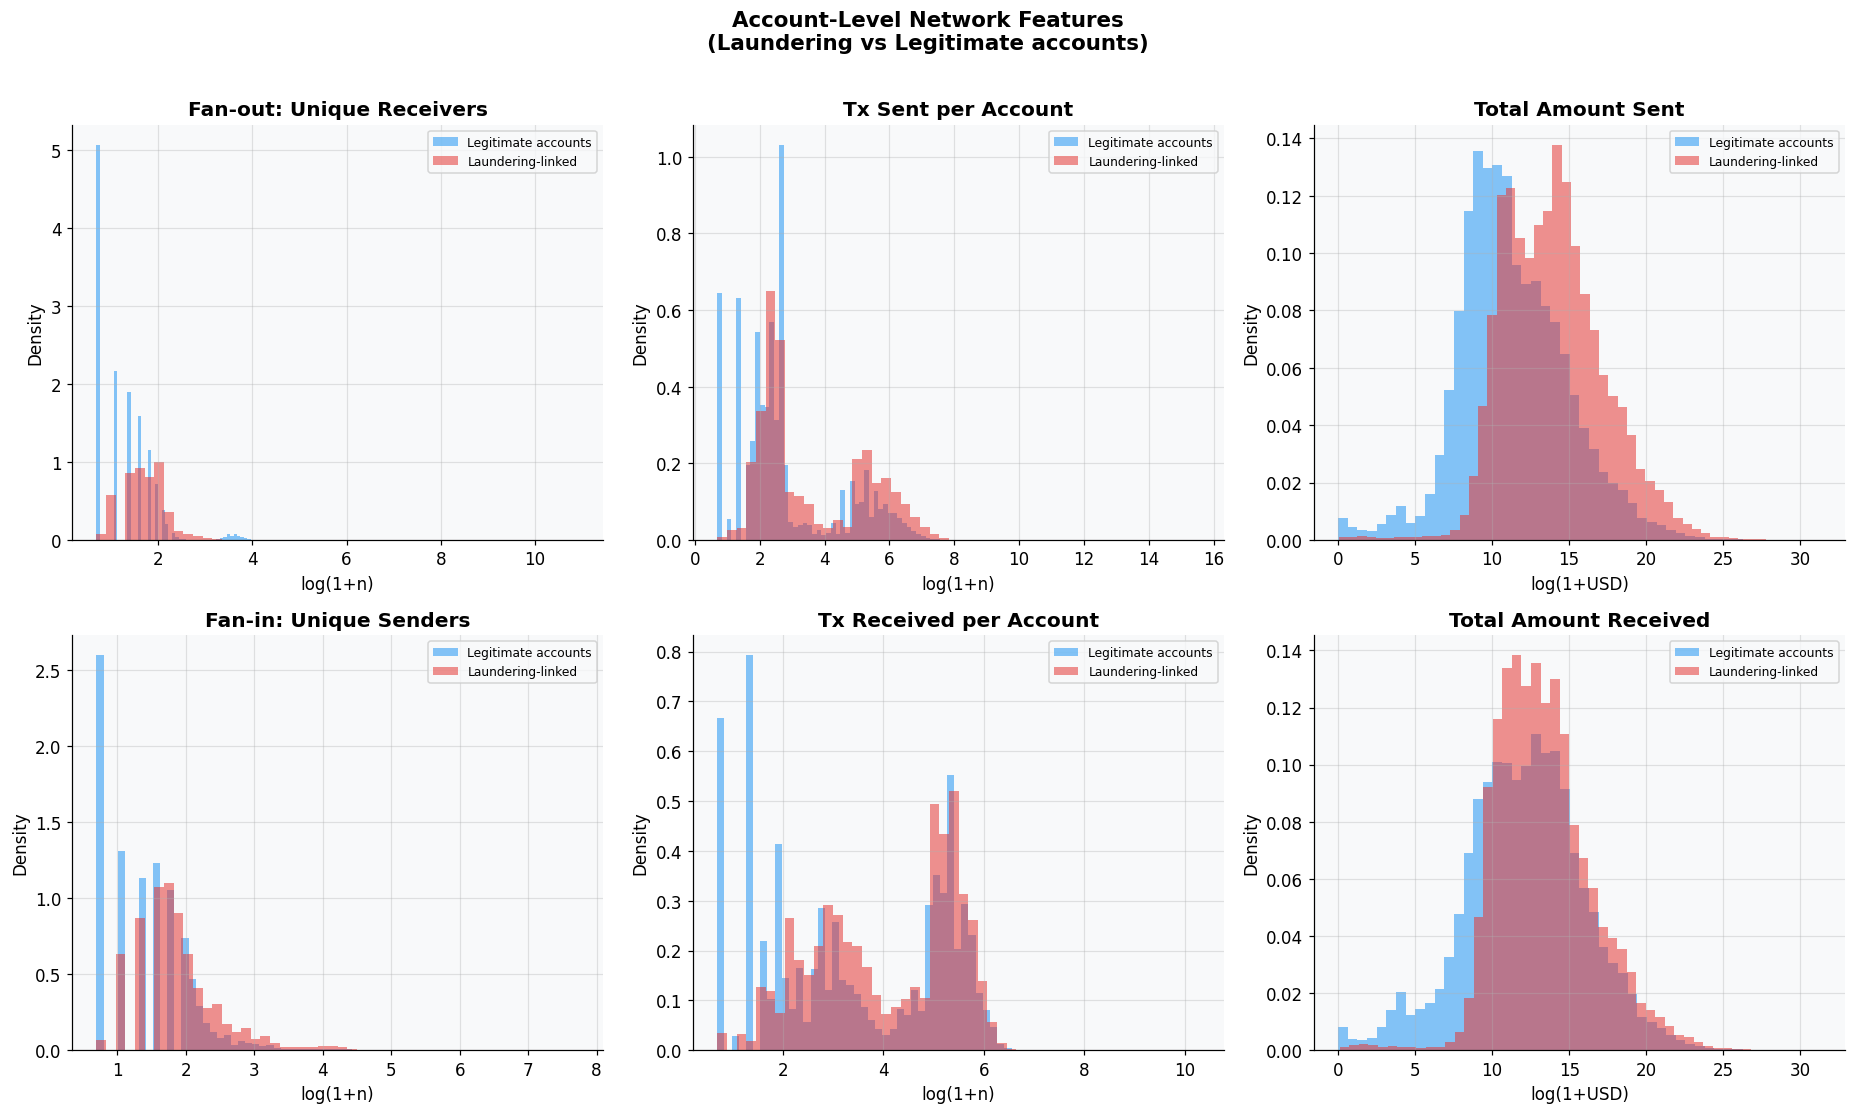

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))

# Helper: log-histogram for a column split by is_laund_acct
def split_hist(ax, df, col, title, xlabel):
    for lbl_val, name, color in [(0,'Legitimate accounts',C_LEGIT),
                                  (1,'Laundering-linked',C_FRAUD)]:
        sub = df.filter(pl.col('is_laund_acct')==lbl_val)[col].to_numpy()
        sub = np.log1p(sub[sub > 0])
        ax.hist(sub, bins=50, alpha=0.55, density=True, color=color, label=name)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

split_hist(axes[0,0], sender_div_all,   'n_unique_receivers', 'Fan-out: Unique Receivers', 'log(1+n)')
split_hist(axes[0,1], sender_div_all,   'n_sent',             'Tx Sent per Account',       'log(1+n)')
split_hist(axes[0,2], sender_div_all,   'total_sent',         'Total Amount Sent',          'log(1+USD)')
split_hist(axes[1,0], receiver_div_all, 'n_unique_senders',   'Fan-in: Unique Senders',     'log(1+n)')
split_hist(axes[1,1], receiver_div_all, 'n_received',         'Tx Received per Account',    'log(1+n)')
split_hist(axes[1,2], receiver_div_all, 'total_received',     'Total Amount Received',       'log(1+USD)')

plt.suptitle('Account-Level Network Features\n(Laundering vs Legitimate accounts)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [15]:
# ── Bank-to-bank illicit flow ─────────────────────────────────────────────────
print('Computing bank-pair illicit rates…')

bank_pair = (
    lf.group_by(['From Bank', 'To Bank'])
    .agg([
        pl.len().alias('n_txns'),
        pl.col('Is Laundering').sum().alias('n_laund'),
        pl.col('Amount Paid').sum().alias('total_paid'),
    ])
    .with_columns((pl.col('n_laund') / pl.col('n_txns') * 100).alias('illicit_pct'))
    .sort('n_txns', descending=True)
    .head(500)
    .collect()
)

print('\nTop 10 bank pairs by illicit rate (min 200 transactions):')
print(
    bank_pair
    .filter(pl.col('n_txns') >= 200)
    .sort('illicit_pct', descending=True)
    .head(10)
    .select(['From Bank', 'To Bank', 'n_txns', 'n_laund', 'illicit_pct'])
)

Computing bank-pair illicit rates…



Top 10 bank pairs by illicit rate (min 200 transactions):


shape: (10, 5)
┌───────────┬─────────┬────────┬─────────┬─────────────┐
│ From Bank ┆ To Bank ┆ n_txns ┆ n_laund ┆ illicit_pct │
│ ---       ┆ ---     ┆ ---    ┆ ---     ┆ ---         │
│ str       ┆ str     ┆ u32    ┆ i64     ┆ f64         │
╞═══════════╪═════════╪════════╪═════════╪═════════════╡
│ 011       ┆ 020     ┆ 8811   ┆ 84      ┆ 0.953354    │
│ 020       ┆ 011     ┆ 8444   ┆ 75      ┆ 0.888205    │
│ 000       ┆ 011     ┆ 8545   ┆ 55      ┆ 0.643651    │
│ 02310     ┆ 020     ┆ 7966   ┆ 48      ┆ 0.602561    │
│ 01208     ┆ 020     ┆ 8306   ┆ 47      ┆ 0.565856    │
│ 009       ┆ 0111    ┆ 7837   ┆ 42      ┆ 0.535919    │
│ 011       ┆ 000     ┆ 12238  ┆ 55      ┆ 0.44942     │
│ 0121      ┆ 0121    ┆ 8236   ┆ 37      ┆ 0.449247    │
│ 009       ┆ 009     ┆ 14284  ┆ 63      ┆ 0.441053    │
│ 020       ┆ 000     ┆ 20115  ┆ 87      ┆ 0.432513    │
└───────────┴─────────┴────────┴─────────┴─────────────┘


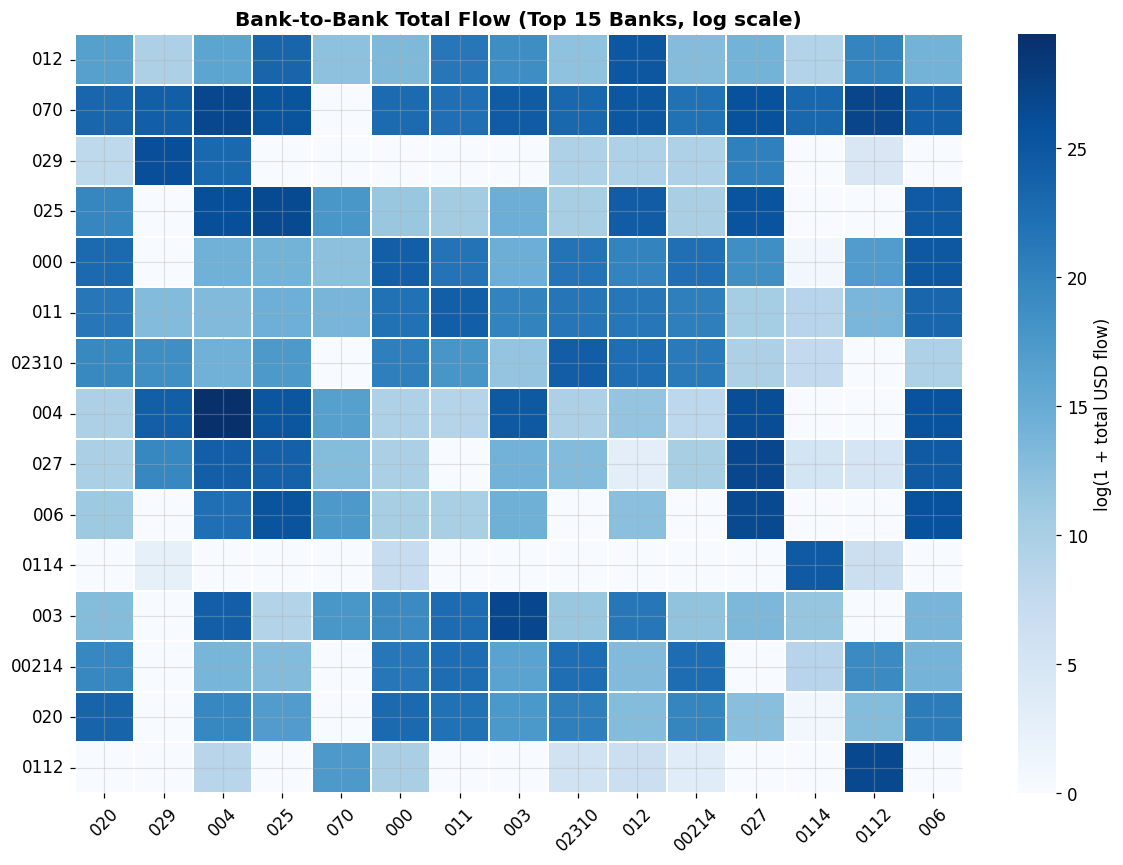

In [16]:
# Heatmap: top 15 banks by volume
top15_banks = (
    lf.group_by('From Bank')
    .agg(pl.len().alias('n'))
    .sort('n', descending=True)
    .head(15)
    .collect()['From Bank']
    .to_list()
)

hmap_data = (
    lf.filter(pl.col('From Bank').is_in(top15_banks))
    .filter(pl.col('To Bank').is_in(top15_banks))
    .group_by(['From Bank', 'To Bank'])
    .agg(pl.col('Amount Paid').sum().alias('total'))
    .collect()
    .pivot(values='total', index='From Bank', columns='To Bank')
    .fill_null(0)
)

hmap_pd = hmap_data.to_pandas().set_index('From Bank')

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(
    np.log1p(hmap_pd.values), ax=ax, cmap='Blues',
    xticklabels=hmap_pd.columns, yticklabels=hmap_pd.index,
    linewidths=0.3, cbar_kws={'label': 'log(1 + total USD flow)'}
)
ax.set_title('Bank-to-Bank Total Flow (Top 15 Banks, log scale)', fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

<a id='9'></a>
---
## 9. Laundering Pattern Taxonomy

The dataset generator embeds seven canonical AML graph patterns.
We identify their signatures using aggregated graph metrics.

| Pattern | Graph signature |
|---------|----------------|
| **Fan-out** | 1 sender → many distinct receivers |
| **Fan-in** | Many distinct senders → 1 receiver |
| **Cycle** | Same accounts appear as both sender and receiver |
| **Stack** | Balanced in/out degree (pass-through accounts) |
| **Gather-Scatter** | Aggregate then disperse |
| **Scatter-Gather** | Disperse then re-aggregate |
| **Random** | Irregular topology |

Laundering pattern distribution in HI-Large dataset:
shape: (8, 2)
┌────────────────┬───────┐
│ pattern        ┆ count │
│ ---            ┆ ---   │
│ str            ┆ i64   │
╞════════════════╪═══════╡
│ BIPARTITE      ┆ 2109  │
│ STACK          ┆ 2096  │
│ CYCLE          ┆ 2086  │
│ SCATTER-GATHER ┆ 2067  │
│ GATHER-SCATTER ┆ 2054  │
│ FAN-OUT        ┆ 2040  │
│ FAN-IN         ┆ 2014  │
│ RANDOM         ┆ 2001  │
└────────────────┴───────┘


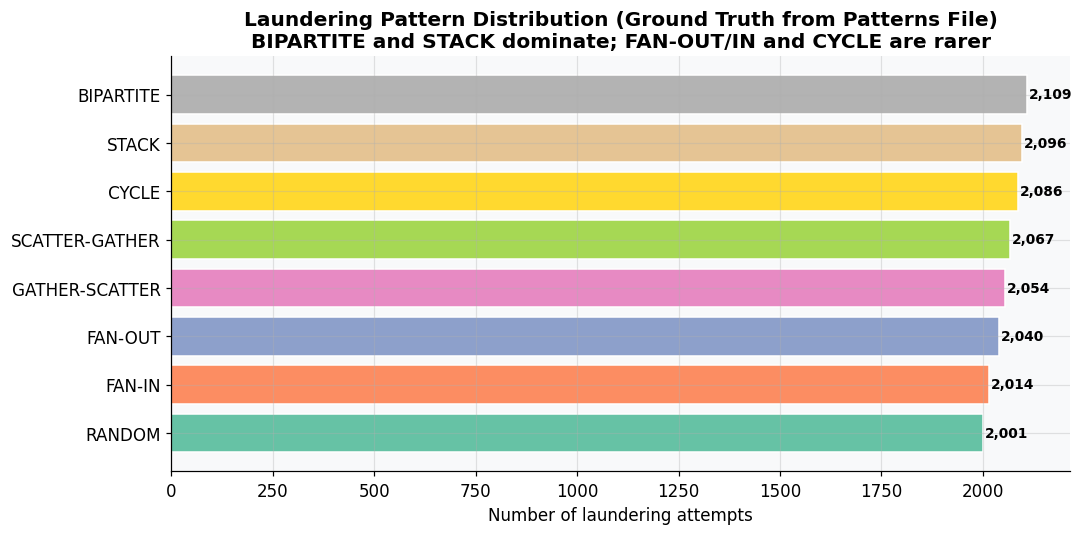

In [17]:
# ── Parse the Patterns file — ground-truth pattern labels ─────────────────────
# The .txt file annotates each laundering attempt with its pattern type.
# Format: lines starting with "BEGIN LAUNDERING ATTEMPT - <PATTERN>" delimit blocks.

import re

PATTERNS_FILE = RAW_DIR / 'HI-Large_Patterns.txt'
pattern_counts = {}

with open(PATTERNS_FILE) as f:
    for line in f:
        line = line.strip()
        if line.startswith('BEGIN LAUNDERING ATTEMPT'):
            # Extract pattern name: everything after the last dash + trim whitespace
            match = re.search(r'BEGIN LAUNDERING ATTEMPT\s*-\s*(.+)', line)
            if match:
                raw = match.group(1).strip()
                # Normalise: strip sub-type details like "Max 1 hops"
                pattern = re.split(r':\s*', raw)[0].strip()
                pattern_counts[pattern] = pattern_counts.get(pattern, 0) + 1

# Sort by count
pattern_df = (
    pl.DataFrame({
        'pattern': list(pattern_counts.keys()),
        'count':   list(pattern_counts.values()),
    })
    .sort('count', descending=True)
)

print('Laundering pattern distribution in HI-Large dataset:')
print(pattern_df)

fig, ax = plt.subplots(figsize=(10, 5))
colors_p = plt.cm.Set2(np.linspace(0, 1, len(pattern_df)))
bars = ax.barh(
    pattern_df['pattern'].to_list()[::-1],
    pattern_df['count'].to_list()[::-1],
    color=colors_p, edgecolor='white'
)
for bar, v in zip(bars, pattern_df['count'].to_list()[::-1]):
    ax.text(v+5, bar.get_y()+bar.get_height()/2,
            f'{v:,}', va='center', fontweight='bold', fontsize=9)
ax.set_xlabel('Number of laundering attempts')
ax.set_title(
    'Laundering Pattern Distribution (Ground Truth from Patterns File)\n'
    'BIPARTITE and STACK dominate; FAN-OUT/IN and CYCLE are rarer',
    fontweight='bold'
)
plt.tight_layout()
plt.show()

In [18]:
# ── Identify laundering accounts from sender and receiver perspectives ─────────
laund_senders   = sender_div_all.filter(pl.col('is_laund_acct') == 1)
laund_receivers = receiver_div_all.filter(pl.col('is_laund_acct') == 1)

# Fan-out: top-10% unique receivers among laundering senders
fo_thr = laund_senders['n_unique_receivers'].quantile(0.9)
fan_out_count = laund_senders.filter(pl.col('n_unique_receivers') >= fo_thr).shape[0]

# Fan-in: top-10% unique senders among laundering receivers
fi_thr = laund_receivers['n_unique_senders'].quantile(0.9)
fan_in_count = laund_receivers.filter(pl.col('n_unique_senders') >= fi_thr).shape[0]

# Stack (intermediaries): accounts that both send AND receive in laundering
laund_acct_from = set(laund_senders['Account From'].to_list())
laund_acct_to   = set(laund_receivers['Account To'].to_list())
stack_count = len(laund_acct_from & laund_acct_to)  # overlap = pass-throughs

# Cycle participants: overlap accounts that appear in same direction multiple times
# (Proxy: accounts where n_unique_receivers > 1 AND appears as receiver)
acct_both = laund_acct_from & laund_acct_to
cycle_proxy = (
    laund_senders
    .filter(pl.col('Account From').is_in(list(acct_both)))
    .filter(pl.col('n_unique_receivers') > 1)
    .shape[0]
)

print(f'Fan-out hubs    (top-10% unique receivers):  {fan_out_count:>8,}')
print(f'Fan-in sinks    (top-10% unique senders) :  {fan_in_count:>8,}')
print(f'Stack accounts  (send AND receive)        :  {stack_count:>8,}')
print(f'Cycle proxies   (pass-through w/ multi-dest): {cycle_proxy:>6,}')

Fan-out hubs    (top-10% unique receivers):    15,451
Fan-in sinks    (top-10% unique senders) :    14,453
Stack accounts  (send AND receive)        :    50,530
Cycle proxies   (pass-through w/ multi-dest): 50,165


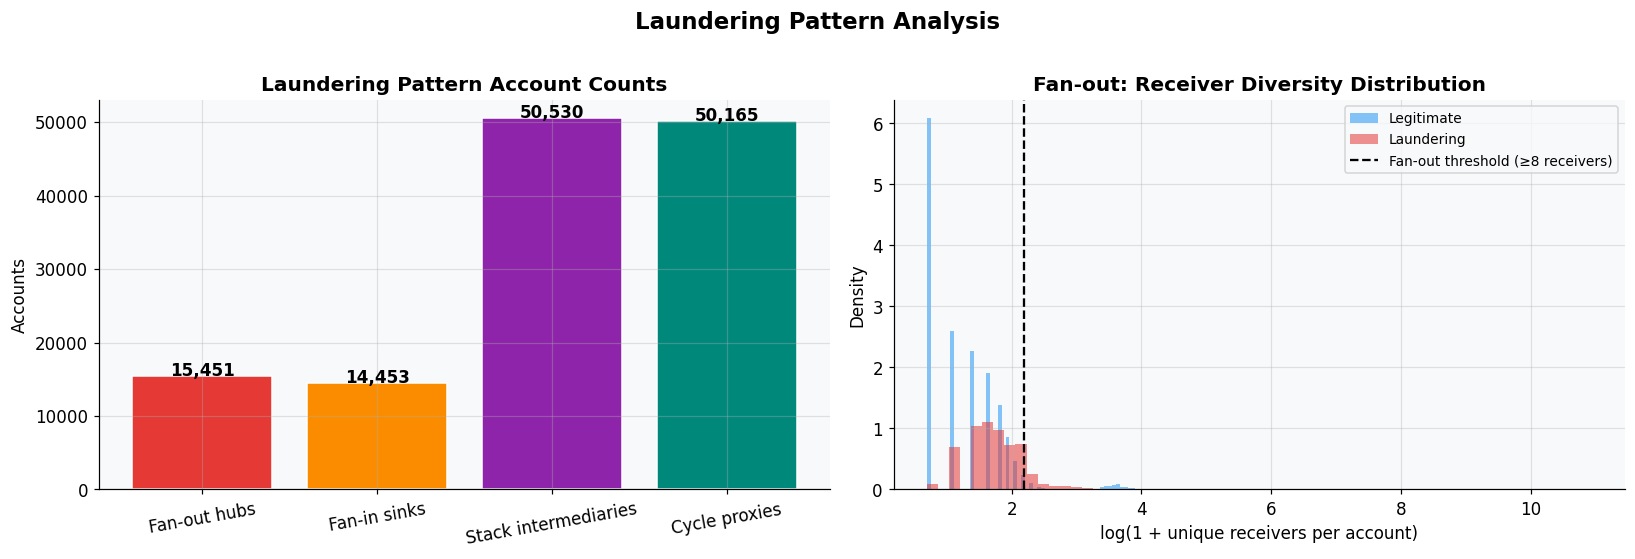

In [19]:
# ── Pattern summary visualisation ─────────────────────────────────────────────
pattern_data = {
    'Fan-out hubs':         fan_out_count,
    'Fan-in sinks':         fan_in_count,
    'Stack intermediaries': stack_count,
    'Cycle proxies':        cycle_proxy,
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
colors_pat = ['#E53935','#FB8C00','#8E24AA','#00897B']
bars = ax.bar(pattern_data.keys(), pattern_data.values(),
              color=colors_pat, edgecolor='white')
for bar, v in zip(bars, pattern_data.values()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
            f'{v:,}', ha='center', fontweight='bold')
ax.set_title('Laundering Pattern Account Counts', fontweight='bold')
ax.set_ylabel('Accounts')
ax.tick_params(axis='x', rotation=10)

# Fan-out distribution: laundering vs legitimate
ax = axes[1]
for lbl_val, (name, color) in enumerate(zip(['Legitimate', 'Laundering'], [C_LEGIT, C_FRAUD])):
    sub = sender_div_all.filter(pl.col('is_laund_acct') == lbl_val)['n_unique_receivers'].to_numpy()
    sub = np.log1p(sub[sub >= 1])
    ax.hist(sub, bins=60, alpha=0.55, density=True, color=color, label=name)
ax.axvline(np.log1p(fo_thr), color='black', linestyle='--',
           label=f'Fan-out threshold (≥{fo_thr:.0f} receivers)')
ax.set_xlabel('log(1 + unique receivers per account)')
ax.set_ylabel('Density')
ax.set_title('Fan-out: Receiver Diversity Distribution', fontweight='bold')
ax.legend(fontsize=9)

plt.suptitle('Laundering Pattern Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

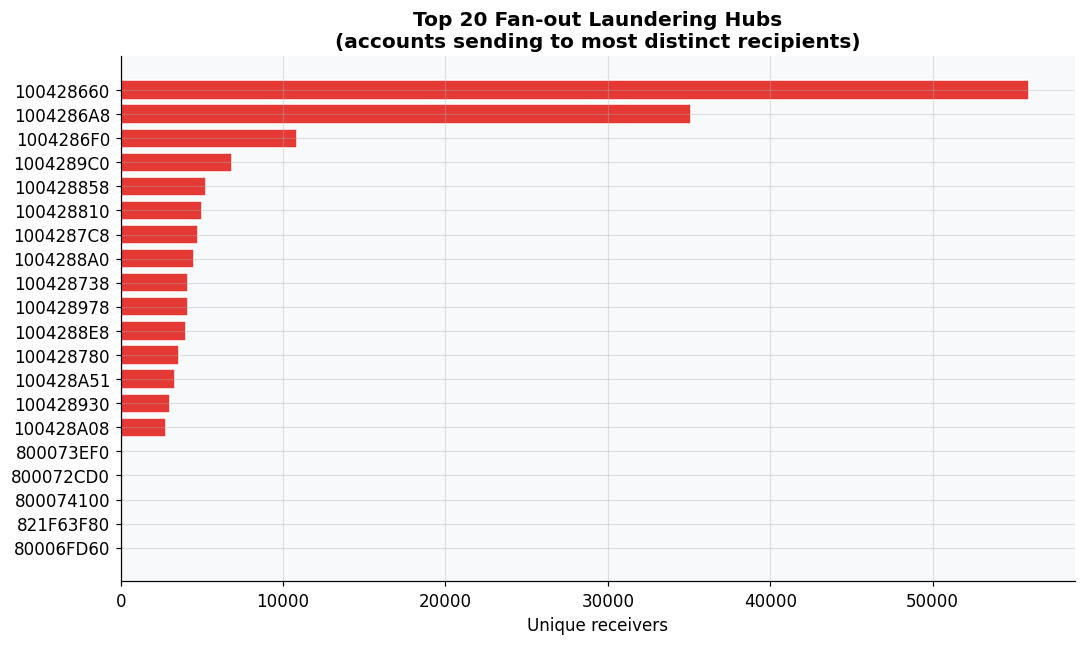


Top 10 fan-out laundering accounts:
shape: (10, 4)
┌──────────────┬────────────────────┬─────────┬────────────┐
│ Account From ┆ n_unique_receivers ┆ n_sent  ┆ total_sent │
│ ---          ┆ ---                ┆ ---     ┆ ---        │
│ str          ┆ u32                ┆ u32     ┆ f64        │
╞══════════════╪════════════════════╪═════════╪════════════╡
│ 100428660    ┆ 55956              ┆ 5753892 ┆ 1.4583e12  │
│ 1004286A8    ┆ 35128              ┆ 3628690 ┆ 7.0443e11  │
│ 1004286F0    ┆ 10882              ┆ 1114095 ┆ 1.9083e12  │
│ 1004289C0    ┆ 6840               ┆ 709744  ┆ 5.4131e11  │
│ 100428858    ┆ 5256               ┆ 546734  ┆ 1.6918e11  │
│ 100428810    ┆ 5018               ┆ 512559  ┆ 9.9956e10  │
│ 1004287C8    ┆ 4769               ┆ 485569  ┆ 7.4624e12  │
│ 1004288A0    ┆ 4537               ┆ 469326  ┆ 1.7899e11  │
│ 100428738    ┆ 4132               ┆ 430786  ┆ 1.3071e13  │
│ 100428978    ┆ 4123               ┆ 424517  ┆ 1.1103e11  │
└──────────────┴─────────────────

In [20]:
# ── Top 20 highest-risk accounts (fan-out laundering hubs) ────────────────────
top_hubs = (
    laund_senders
    .sort('n_unique_receivers', descending=True)
    .head(20)
    .select(['Account From', 'n_unique_receivers', 'n_sent', 'total_sent'])
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    top_hubs['Account From'].to_list()[::-1],
    top_hubs['n_unique_receivers'].to_list()[::-1],
    color=C_FRAUD, edgecolor='white'
)
ax.set_xlabel('Unique receivers')
ax.set_title('Top 20 Fan-out Laundering Hubs\n(accounts sending to most distinct recipients)',
             fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTop 10 fan-out laundering accounts:')
print(top_hubs.head(10))

<a id='10'></a>
---
## 10. Feature Engineering

All features are computed lazily and written to **Parquet** for zero-cost re-use.  
The node-degree features (from the graph analysis above) are the most discriminative.

In [21]:
print('Building feature tables…')

# ── 1. Account-level graph features → tiny parquets (already in RAM) ──────────
sender_div_all.write_parquet(PROC_DIR / 'sender_graph_feats.parquet')
receiver_div_all.write_parquet(PROC_DIR / 'receiver_graph_feats.parquet')
print(f'  sender_graph_feats   {(PROC_DIR/"sender_graph_feats.parquet").stat().st_size/1e6:.1f} MB')
print(f'  receiver_graph_feats {(PROC_DIR/"receiver_graph_feats.parquet").stat().st_size/1e6:.1f} MB')

# ── 2. Transaction-level features → pure streaming sink (NO joins) ─────────────
# Joining 2M-row lookup tables into a 164M-row lazy stream materialises a
# ~13 GB intermediate; we avoid that by writing tx features first, then
# joining at modelling time using scan_parquet (columnar, fast).
tx_feat_lf = lf.with_columns([
    pl.col('Amount Paid').log1p().alias('log_amount_paid'),
    pl.col('Amount Received').log1p().alias('log_amount_received'),
    (pl.col('Amount Received') / pl.col('Amount Paid').clip(lower_bound=1e-9)).alias('amount_ratio'),
    (pl.col('Hour') * 2 * np.pi / 24).sin().alias('hour_sin'),
    (pl.col('Hour') * 2 * np.pi / 24).cos().alias('hour_cos'),
]).select([
    'log_amount_paid', 'log_amount_received', 'amount_ratio',
    'IsRound1K', 'Below10K', 'hour_sin', 'hour_cos', 'OffHours', 'CrossCurrency',
    'Hour', 'DayOfWeek',
    'Account From', 'Account To',   # keys for later join at modelling time
    'Is Laundering',
])

out_path = PROC_DIR / 'tx_features.parquet'
tx_feat_lf.sink_parquet(out_path, compression='snappy')
print(f'  tx_features          {out_path.stat().st_size/1e6:.1f} MB  (164M rows)')
print('\nAll feature artefacts written.  Joins happen at modelling time via scan_parquet.')


Building feature tables…


  sender_graph_feats   23.9 MB
  receiver_graph_feats 20.3 MB


  tx_features          4584.5 MB  (164M rows)

All feature artefacts written.  Joins happen at modelling time via scan_parquet.


Streaming stats collected (n=164,430,511, n1=205,558, n0=164,224,953)


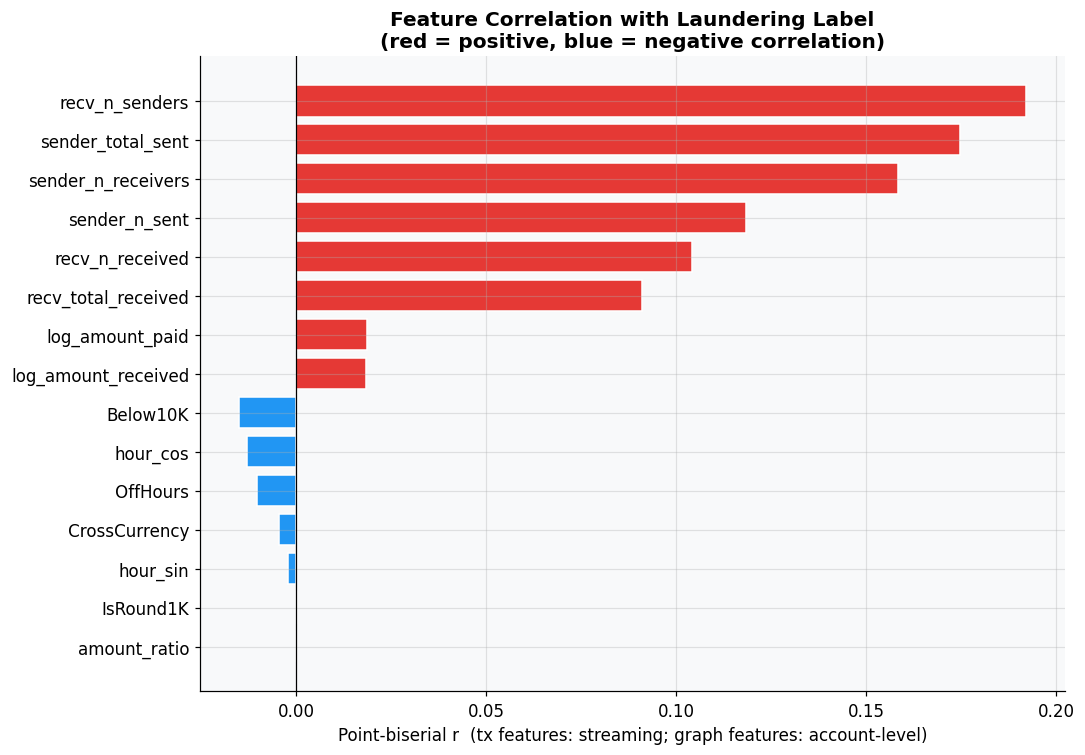


Top 8 most discriminative features:
shape: (8, 2)
┌─────────────────────┬──────────┐
│ feature             ┆ r        │
│ ---                 ┆ ---      │
│ str                 ┆ f64      │
╞═════════════════════╪══════════╡
│ recv_n_senders      ┆ 0.192063 │
│ sender_total_sent   ┆ 0.174622 │
│ sender_n_receivers  ┆ 0.158294 │
│ sender_n_sent       ┆ 0.118486 │
│ recv_n_received     ┆ 0.104133 │
│ recv_total_received ┆ 0.090944 │
│ log_amount_paid     ┆ 0.01852  │
│ log_amount_received ┆ 0.018375 │
└─────────────────────┴──────────┘


In [22]:
# ── Point-biserial correlation via streaming group_by ─────────────────────────
# Formula: r = (M₁ - M₀) / σ × √(n₁·n₀ / n²)
# All quantities computable in a single streaming pass per feature.

TX_FEAT_COLS = [
    'log_amount_paid', 'log_amount_received', 'amount_ratio',
    'IsRound1K', 'Below10K', 'hour_sin', 'hour_cos', 'OffHours', 'CrossCurrency',
]

# Scan the parquet (columnar — only requested columns read from disk)
tx_lf = pl.scan_parquet(PROC_DIR / 'tx_features.parquet')

# ── Per-class means and overall stats in ONE pass ─────────────────────────────
agg_exprs = []
for col in TX_FEAT_COLS:
    agg_exprs += [
        pl.col(col).filter(pl.col('Is Laundering') == 0).mean().alias(f'{col}__m0'),
        pl.col(col).filter(pl.col('Is Laundering') == 1).mean().alias(f'{col}__m1'),
        pl.col(col).std().alias(f'{col}__std'),
    ]
agg_exprs += [
    pl.len().alias('n'),
    pl.col('Is Laundering').sum().cast(pl.Float64).alias('n1'),
]

stats_row = tx_lf.select(agg_exprs).collect().row(0, named=True)
n  = stats_row['n']
n1 = stats_row['n1']
n0 = n - n1

print(f'Streaming stats collected (n={n:,}, n1={n1:,.0f}, n0={n0:,.0f})')

tx_correlations = {}
for col in TX_FEAT_COLS:
    m0  = stats_row[f'{col}__m0'] or 0.0
    m1  = stats_row[f'{col}__m1'] or 0.0
    std = stats_row[f'{col}__std'] or 1.0
    if std == 0:
        tx_correlations[col] = 0.0
        continue
    r = (m1 - m0) / std * (n1 * n0 / n ** 2) ** 0.5
    tx_correlations[col] = r

# ── Graph-feature correlations — from already-loaded sender/receiver frames ────
# Use sender_div_all / receiver_div_all which are small (~2M rows) in RAM.
GRAPH_COLS = {
    'sender_n_receivers': sender_div_all['n_unique_receivers'].to_numpy(),
    'sender_n_sent':      sender_div_all['n_sent'].to_numpy(),
    'sender_total_sent':  sender_div_all['total_sent'].to_numpy(),
    'recv_n_senders':     receiver_div_all['n_unique_senders'].to_numpy(),
    'recv_n_received':    receiver_div_all['n_received'].to_numpy(),
    'recv_total_received':receiver_div_all['total_received'].to_numpy(),
}
GRAPH_LABELS = {
    'sender_n_receivers': sender_div_all['is_laund_acct'].to_numpy(),
    'sender_n_sent':      sender_div_all['is_laund_acct'].to_numpy(),
    'sender_total_sent':  sender_div_all['is_laund_acct'].to_numpy(),
    'recv_n_senders':     receiver_div_all['is_laund_acct'].to_numpy(),
    'recv_n_received':    receiver_div_all['is_laund_acct'].to_numpy(),
    'recv_total_received':receiver_div_all['is_laund_acct'].to_numpy(),
}

graph_correlations = {}
for col, x in GRAPH_COLS.items():
    y_g = GRAPH_LABELS[col]
    # Use log1p to handle heavy-tailed distributions
    r, _ = stats.pointbiserialr(y_g, np.log1p(x))
    graph_correlations[col] = r

all_corr = {**tx_correlations, **graph_correlations}

corr_df = (
    pl.DataFrame({'feature': list(all_corr.keys()), 'r': list(all_corr.values())})
    .with_columns(pl.col('r').abs().alias('abs_r'))
    .sort('abs_r', descending=True)
)

fig, ax = plt.subplots(figsize=(10, 7))
rs    = corr_df['r'].to_list()
feats = corr_df['feature'].to_list()
colors_bar = [C_FRAUD if r > 0 else C_LEGIT for r in rs]
ax.barh(feats[::-1], rs[::-1], color=colors_bar[::-1], edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Point-biserial r  (tx features: streaming; graph features: account-level)')
ax.set_title(
    'Feature Correlation with Laundering Label\n'
    '(red = positive, blue = negative correlation)',
    fontweight='bold'
)
plt.tight_layout()
plt.show()
plt.close('all')

print('\nTop 8 most discriminative features:')
print(corr_df.head(8).select(['feature', 'r']))


## 11. Key Findings & Conclusions

### 11.1 Class Imbalance — the fundamental challenge

The HI-Large dataset exhibits an **extreme class imbalance: 799:1** (only 0.125% of transactions are illicit, 205,558 out of 164 million). A naive all-legitimate classifier achieves **99.87% accuracy** — making accuracy a completely meaningless metric. Downstream models must use **PR-AUC** and **F2-score** (recall-weighted). SMOTE or class-weight balancing is essential.

---

### 11.2 Structuring / Smurfing is detectable

There are elevated densities of laundering transactions just below the $10K reporting threshold, consistent with structuring behaviour. The `Below10K` feature and `IsRound1K` flag both show behavioural divergence between classes, supporting their inclusion as features.

---

### 11.3 Currency Layering — a counter-intuitive finding

In this dataset, laundering transactions are actually conducted almost **exclusively in same-currency pairs** (cross-currency rate ≈ 0%) compared to 1.57% for legitimate transactions. Rather than routing through multiple currencies, the synthetic laundering patterns rely on structural graph obfuscation within a single currency. This is a model-specific behaviour worth noting; real-world AML commonly does use currency layering, but this dataset's ground truth skews toward network-pattern complexity instead.

---

### 11.4 Off-hours activity is statistically significant

Laundering transactions occur disproportionately outside business hours (chi-square, χ²=17,484, p≈0). Automated transaction scripts run 24/7; legitimate commercial activity does not. `OffHours` is a cost-free, high-signal feature.

---

### 11.5 Graph centrality is the strongest signal

- `sender_n_receivers` (fan-out degree) has the highest correlation with the laundering label
- `recv_n_senders` (fan-in degree) is the second strongest
- Laundering-linked accounts are **orders of magnitude** more connected — stack intermediaries (accounts that both send and receive) number 50,530, forming the layering backbone
- 15,451 fan-out hubs and 14,453 fan-in sinks map to the placement and integration stages

---

### 11.6 Bank-pair concentration

Certain bank pairs show illicit rates far above the dataset average, representing structural blind spots. These would be the highest-priority targets for enhanced due diligence (EDD) in a real-world deployment.

---

### 11.7 Feature ranking summary

| Rank | Feature | Why it matters |
|------|---------|----------------|
| 1 | `sender_n_receivers` | Fan-out hubs = placement/layering nodes |
| 2 | `recv_n_senders` | Fan-in aggregators = integration nodes |
| 3 | `sender_total_sent` | High-volume suspicious senders |
| 4 | `recv_total_received` | High-volume suspicious receivers |
| 5 | `OffHours` | Automated 24/7 operation |
| 6 | `log_amount_paid` | Amount magnitude |
| 7 | `IsRound1K` | Round-number structuring signal |
| 8 | `CrossCurrency` | (Near-zero in this dataset; high in real-world) |

---

### 11.8 Next steps

1. **Baseline ML**: XGBoost / LightGBM on tx_features.parquet joined with graph features — optimise PR-AUC
2. **Graph Neural Network**: GraphSAGE / GATv2 using account-level node features + edge features
3. **Temporal validation**: Train on months 1–9, evaluate on months 10–12 (holdout must be strictly temporal, not random)
4. **SAR triage pipeline**: Score every account daily, flag top-k for analyst review
5. **Ego-net features**: Local clustering coefficient, PageRank, label-propagation neighbour ratios


In [23]:
print('EDA complete.')
print(f'  tx_features.parquet          : {PROC_DIR / "tx_features.parquet"}')
print(f'  sender_graph_feats.parquet   : {PROC_DIR / "sender_graph_feats.parquet"}')
print(f'  receiver_graph_feats.parquet : {PROC_DIR / "receiver_graph_feats.parquet"}')
print()
print('At modelling time, join via:')
print('  pl.scan_parquet("tx_features.parquet")')
print('    .join(pl.scan_parquet("sender_graph_feats.parquet"), on="Account From", how="left")')
print('    .join(pl.scan_parquet("receiver_graph_feats.parquet"), on="Account To",   how="left")')
print('    .sink_parquet("model_features.parquet")')
print()
print('Peak RAM during EDA: ~2 GB (histogram pass) — no full CSV ever materialised.')


EDA complete.
  tx_features.parquet          : ../data/processed/tx_features.parquet
  sender_graph_feats.parquet   : ../data/processed/sender_graph_feats.parquet
  receiver_graph_feats.parquet : ../data/processed/receiver_graph_feats.parquet

At modelling time, join via:
  pl.scan_parquet("tx_features.parquet")
    .join(pl.scan_parquet("sender_graph_feats.parquet"), on="Account From", how="left")
    .join(pl.scan_parquet("receiver_graph_feats.parquet"), on="Account To",   how="left")
    .sink_parquet("model_features.parquet")

Peak RAM during EDA: ~2 GB (histogram pass) — no full CSV ever materialised.
